# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = 'jiehaoxu1@gmail.com'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/jiehaoxu1@gmail.com/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
%pip install seaborn
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

dataset = datasets.load_iris()
df = pd.DataFrame(
    data=dataset.data,
    columns=dataset.feature_names
)
df['species'] = dataset.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

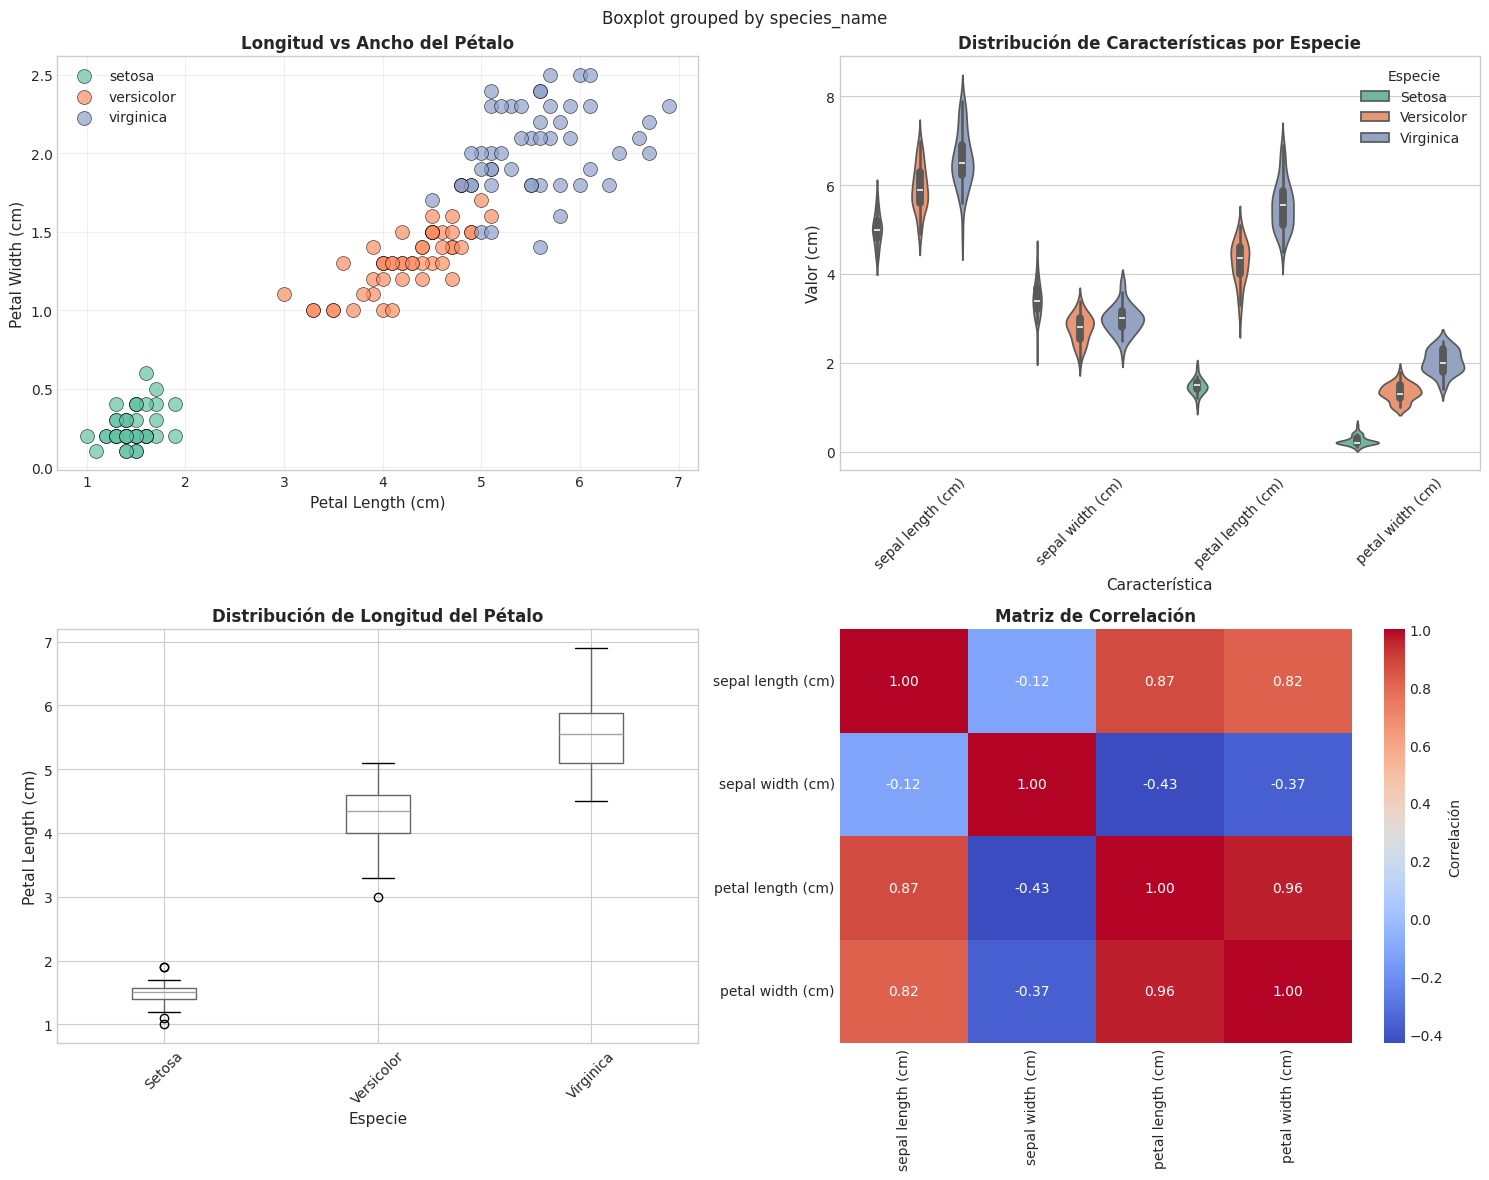

✅ Visualizaciones generadas

🔍 Observaciones clave:
   - Las características del pétalo separan mejor las especies
   - Setosa es claramente separable de las otras dos
   - Versicolor y Virginica tienen mayor solapamiento


In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.

# Crear visualizaciones exploratorias
df['species_name'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor', 
    2: 'Virginica'
})

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis Exploratorio del Dataset Iris', fontsize=16, fontweight='bold')

# Gráfico 1: Pairplot de características más importantes
ax1 = plt.subplot(2, 2, 1)
for species_id, species_name in enumerate(dataset.target_names):
    mask = df['species'] == species_id
    ax1.scatter(
        df[mask]['petal length (cm)'],
        df[mask]['petal width (cm)'],
        label=species_name,
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )
ax1.set_xlabel('Petal Length (cm)', fontsize=11)
ax1.set_ylabel('Petal Width (cm)', fontsize=11)
ax1.set_title('Longitud vs Ancho del Pétalo', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de características por especie
ax2 = plt.subplot(2, 2, 2)
df_melted = df[['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)', 'species_name']].melt(
    id_vars='species_name',
    var_name='feature',
    value_name='value'
)
sns.violinplot(data=df_melted, x='feature', y='value', hue='species_name', ax=ax2)
ax2.set_xlabel('Característica', fontsize=11)
ax2.set_ylabel('Valor (cm)', fontsize=11)
ax2.set_title('Distribución de Características por Especie', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Especie')

# Gráfico 3: Boxplot de longitud del pétalo
ax3 = plt.subplot(2, 2, 3)
df.boxplot(column='petal length (cm)', by='species_name', ax=ax3)
ax3.set_xlabel('Especie', fontsize=11)
ax3.set_ylabel('Petal Length (cm)', fontsize=11)
ax3.set_title('Distribución de Longitud del Pétalo', fontweight='bold')
plt.sca(ax3)
plt.xticks(rotation=45)

# Gráfico 4: Correlación entre características
ax4 = plt.subplot(2, 2, 4)
correlation = df[dataset.feature_names].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=ax4,
            cbar_kws={'label': 'Correlación'})
ax4.set_title('Matriz de Correlación', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("\n🔍 Observaciones clave:")
print("   - Las características del pétalo separan mejor las especies")
print("   - Setosa es claramente separable de las otras dos")
print("   - Versicolor y Virginica tienen mayor solapamiento")


## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
X = dataset.data
y = dataset.target

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.
print(f"Total de muestras: {len(X)}")
print(f"\nConjunto de Entrenamiento:")
print(f"    Muestras: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"    Shape: {X_train.shape}")
print(f"    Distribución de clases:")
unique, counts = np.unique(y_train, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"     • {dataset.target_names[class_id]}: {count} muestras")

print(f"\nConjunto de Prueba:")
print(f"   - Muestras: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Shape: {X_test.shape}")
print(f"   - Distribución de clases:")
unique, counts = np.unique(y_test, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"     • {dataset.target_names[class_id]}: {count} muestras")

Total de muestras: 150

Conjunto de Entrenamiento:
    Muestras: 120 (80.0%)
    Shape: (120, 4)
    Distribución de clases:
     • setosa: 40 muestras
     • versicolor: 40 muestras
     • virginica: 40 muestras

Conjunto de Prueba:
   - Muestras: 30 (20.0%)
   - Shape: (30, 4)
   - Distribución de clases:
     • setosa: 10 muestras
     • versicolor: 10 muestras
     • virginica: 10 muestras


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/09/27 16:39:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 16:39:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 16:39:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ea0f21a9-b44d.cloud.databricks.com/ml/experiments/1075234415397022/models/m-700896c1b27d44a9aae3356ef15c0b73?o=7474652659743179
2026/09/27 16:39:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

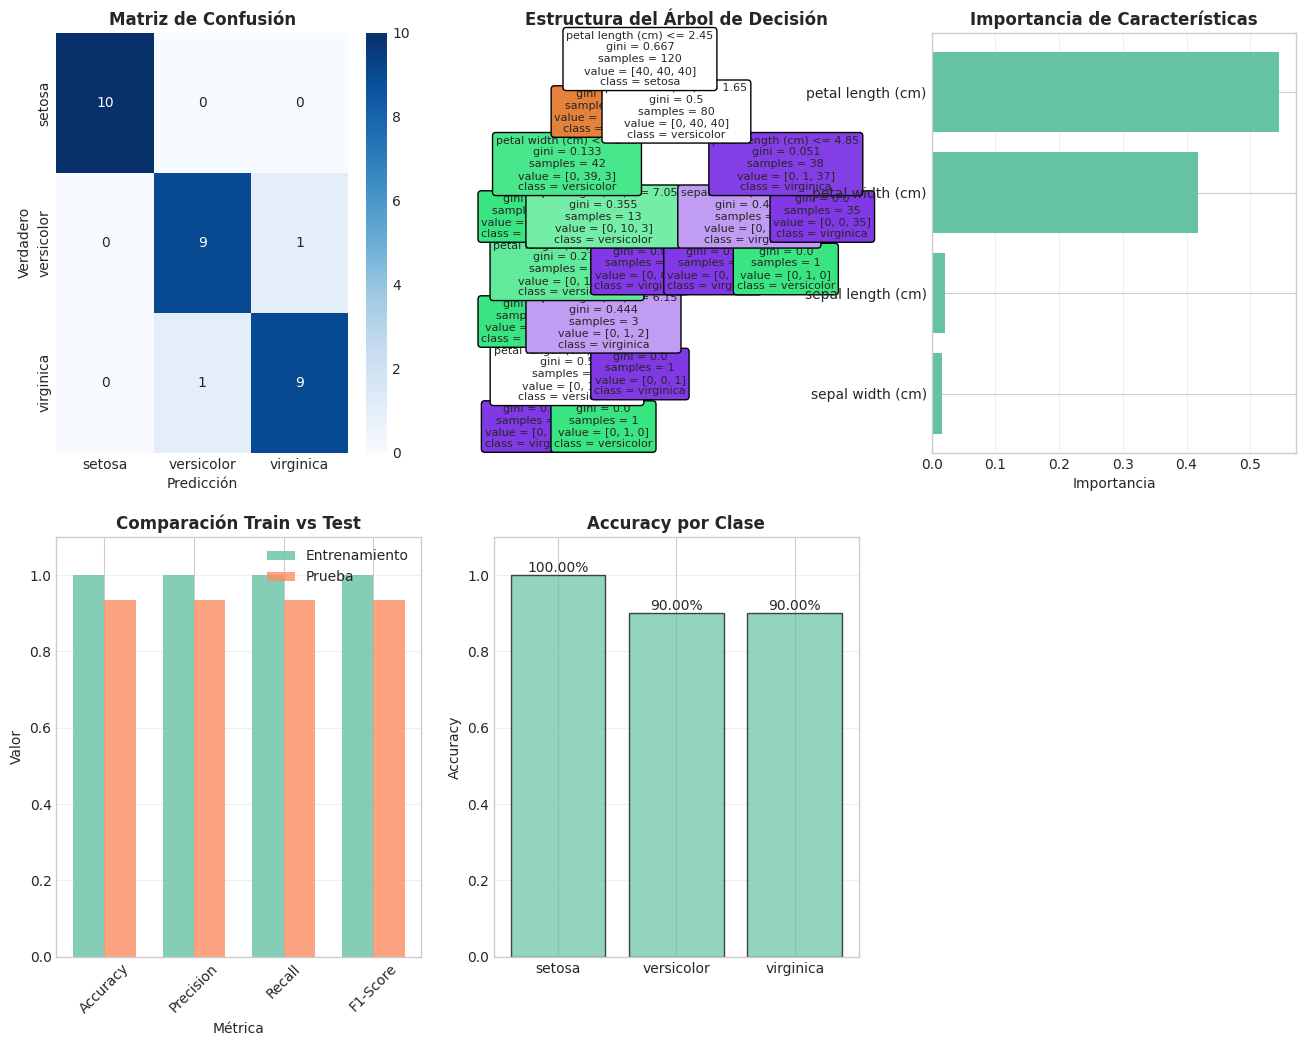

🎯 Accuracy (Test): 0.9333 (93.33%)
🌟 F1-Score (Test): 0.9333
📊 Cross-Val Accuracy: 0.9583 ± 0.0264


In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
#     TODO: Define hiperparámetros del árbol.
    max_depth = 10        # Profundidad máxima del árbol    
    max_features = 2      # Número máximo de características por split
    min_samples_split = 2 # Mínimo de muestras para hacer un split
    min_samples_leaf = 1  # Mínimo de muestras en hoja
    random_state = 42     # Reproducibilidad
#
#     TODO: Crea y entrena DecisionTreeClassifier.
    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )
    dt.fit(X_train, y_train)
#
#     TODO: Genera predicciones para train y test.
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
#
#     TODO: Calcula métricas de clasificación.
    # Métricas de entrenamiento
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    recall_train = recall_score(y_train, y_pred_train, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    
    # Métricas de prueba
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
#
#     TODO: Evalúa con cross-validation.
    cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
#
#     TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("max_features", max_features)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("min_samples_leaf", min_samples_leaf)
    mlflow.log_param("dataset", "Iris")
    mlflow.log_param("n_classes", len(dataset.target_names))



    

#     TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
# Figura con múltiples análisis
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Matriz de Confusión
    ax1 = plt.subplot(2, 3, 1)
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=dataset.target_names,
                yticklabels=dataset.target_names)
    ax1.set_title('Matriz de Confusión', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Verdadero', fontsize=10)
    ax1.set_xlabel('Predicción', fontsize=10)
    
    # 2. Visualización del Árbol
    ax2 = plt.subplot(2, 3, 2)
    plot_tree(dt, 
              feature_names=dataset.feature_names,
              class_names=dataset.target_names,
              filled=True,
              rounded=True,
              ax=ax2,
              fontsize=8)
    ax2.set_title('Estructura del Árbol de Decisión', fontweight='bold', fontsize=12)
    
    # 3. Importancia de Características
    ax3 = plt.subplot(2, 3, 3)
    feature_importance = pd.DataFrame({
        'feature': dataset.feature_names,
        'importance': dt.feature_importances_
    }).sort_values('importance', ascending=True)
    ax3.barh(feature_importance['feature'], feature_importance['importance'])
    ax3.set_xlabel('Importancia', fontsize=10)
    ax3.set_title('Importancia de Características', fontweight='bold', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # 4. Comparación de Métricas
    ax4 = plt.subplot(2, 3, 4)
    metrics_comparison = pd.DataFrame({
        'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Entrenamiento': [accuracy_train, precision_train, recall_train, f1_train],
        'Prueba': [accuracy_test, precision_test, recall_test, f1_test]
    })
    x = np.arange(len(metrics_comparison))
    width = 0.35
    ax4.bar(x - width/2, metrics_comparison['Entrenamiento'], width, label='Entrenamiento', alpha=0.8)
    ax4.bar(x + width/2, metrics_comparison['Prueba'], width, label='Prueba', alpha=0.8)
    ax4.set_xlabel('Métrica', fontsize=10)
    ax4.set_ylabel('Valor', fontsize=10)
    ax4.set_title('Comparación Train vs Test', fontweight='bold', fontsize=12)
    ax4.set_xticks(x)
    ax4.set_xticklabels(metrics_comparison['Métrica'], rotation=45)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim([0, 1.1])
    
    # 5. Predicciones por clase
    ax5 = plt.subplot(2, 3, 5)
    class_accuracy = []
    for i, class_name in enumerate(dataset.target_names):
        mask = y_test == i
        if mask.sum() > 0:
            acc = accuracy_score(y_test[mask], y_pred_test[mask])
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    
    bars = ax5.bar(dataset.target_names, class_accuracy, alpha=0.7, edgecolor='black')
    for bar, acc in zip(bars, class_accuracy):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2%}', ha='center', va='bottom', fontsize=10)
    ax5.set_ylabel('Accuracy', fontsize=10)
    ax5.set_title('Accuracy por Clase', fontweight='bold', fontsize=12)
    ax5.set_ylim([0, 1.1])
    ax5.grid(True, alpha=0.3, axis='y')
    
    
    
    # Guardar en MLflow
    mlflow.log_figure(fig, "model_analysis_complete.png")
    plt.show()

    
    print(f"🎯 Accuracy (Test): {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
    print(f"🌟 F1-Score (Test): {f1_test:.4f}")
    print(f"📊 Cross-Val Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    
#     TODO: Escribe una breve interpretación de los resultados.
# El modelo obtiene un 93,33 % de accuracy en test y un F1-score de 0,9333, lo que indica un rendimiento alto y equilibrado entre precisión y recall. Además, la validación cruzada alcanza una accuracy media del 95,83 %, con una desviación estándar de 0,0264, lo que sugiere que el modelo mantiene un comportamiento bastante estable entre las distintas particiones


## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**
- ¿Qué ventajas tiene un árbol de decisión?
- ¿Qué riesgos tiene respecto a overfitting?
- ¿Cómo interpretarías una matriz de confusión multiclase?

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.

# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
# configuraciones = [...]
# for config in configuraciones:
#     # Entrena, evalúa y registra cada configuración en MLflow
#     pass

# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena y compara métricas
#     pass

# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
# incorrect_indices = ...
# TODO: inspecciona las muestras mal clasificadas.

# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = ...
